# 🔍 FraudLens — Exploratory Data Analysis (01_eda)

**Goal:** Understand the structure, quality, and fraud signal of two independent datasets:
1. **IEEE-CIS Fraud Detection** (Kaggle) — e-commerce transaction data with rich V-features
2. **PaySim** — synthetic mobile-money transaction data

> ⚠️ These two datasets have **completely different schemas** and are kept **separate** throughout this notebook.  
> The IEEE-CIS **test** files are holdout competition data with no labels — they are **not used** here.

---

## 0. Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

# ---------- Paths ----------
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR   = os.path.join(BASE_DIR, 'data')
IEEE_DIR   = os.path.join(DATA_DIR, 'ieee-cis')
PAYSIM_DIR = os.path.join(DATA_DIR, 'paysim')
REPORTS    = os.path.join(BASE_DIR, 'reports')
os.makedirs(REPORTS, exist_ok=True)

print(f'Base dir : {BASE_DIR}')
print(f'Reports  : {REPORTS}')
print(f'Pandas   : {pd.__version__}  |  NumPy : {np.__version__}  |  Seaborn : {sns.__version__}')


Base dir : c:\Users\DHANRAJ\fraudlens
Reports  : c:\Users\DHANRAJ\fraudlens\reports
Pandas   : 3.0.0  |  NumPy : 2.2.6  |  Seaborn : 0.13.2


---
# Part 1 — IEEE-CIS Fraud Detection Dataset

The IEEE-CIS dataset contains:
- **Transaction table** — ~590K rows, ~393 columns including Vesta proprietary V-features
- **Identity table** — ~144K rows of device/network info, joinable on `TransactionID`

The join is a **left join** (transaction → identity) because not every transaction has identity info.

## 1.1 Load IEEE-CIS Data

In [2]:
print('Loading train_transaction.csv  (may take ~30s on first run) ...')
txn = pd.read_csv(os.path.join(IEEE_DIR, 'train_transaction.csv'))
print(f'  train_transaction shape : {txn.shape}')

print('Loading train_identity.csv ...')
idn = pd.read_csv(os.path.join(IEEE_DIR, 'train_identity.csv'))
print(f'  train_identity    shape : {idn.shape}')


Loading train_transaction.csv  (may take ~30s on first run) ...
  train_transaction shape : (590540, 394)
Loading train_identity.csv ...
  train_identity    shape : (144233, 41)


In [3]:
# ---------- Left-join: transaction <- identity ----------
ieee = txn.merge(idn, on='TransactionID', how='left')
print(f'Merged IEEE-CIS shape : {ieee.shape}')

# % of transactions with a matching identity record
matched        = txn['TransactionID'].isin(idn['TransactionID']).sum()
pct_with_id    = matched / len(txn) * 100
pct_without_id = 100 - pct_with_id

print('\n--- Identity Record Coverage ---')
print(f'  Transactions WITH    identity info : {matched:,}  ({pct_with_id:.1f}%)')
print(f'  Transactions WITHOUT identity info : {len(txn) - matched:,}  ({pct_without_id:.1f}%)')
print(f'  Total transactions                 : {len(txn):,}')


Merged IEEE-CIS shape : (590540, 434)

--- Identity Record Coverage ---
  Transactions WITH    identity info : 144,233  (24.4%)
  Transactions WITHOUT identity info : 446,307  (75.6%)
  Total transactions                 : 590,540


## 1.2 Shape & Data Types

In [4]:
print('IEEE-CIS merged dataset')
print(f'  Rows    : {ieee.shape[0]:,}')
print(f'  Columns : {ieee.shape[1]:,}')

num_cols = ieee.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ieee.select_dtypes(include=['object', 'category']).columns.tolist()

print('\n--- Data Types ---')
print(f'  Numeric columns     : {len(num_cols)}')
print(f'  Categorical columns : {len(cat_cols)}')
print(f'  (Total)             : {len(num_cols) + len(cat_cols)}')


IEEE-CIS merged dataset
  Rows    : 590,540
  Columns : 434

--- Data Types ---
  Numeric columns     : 403
  Categorical columns : 31
  (Total)             : 434


## 1.3 Class Imbalance — IEEE-CIS

Class imbalance is **critical** before any modeling choice. High imbalance means accuracy is misleading; we will need strategies like SMOTE, class weighting, or threshold tuning.

In [5]:
fraud_counts_ieee = ieee['isFraud'].value_counts().sort_index()
total_ieee        = len(ieee)

pct_fraud_ieee = fraud_counts_ieee[1] / total_ieee * 100
pct_legit_ieee = fraud_counts_ieee[0] / total_ieee * 100
ratio_ieee     = fraud_counts_ieee[0] / fraud_counts_ieee[1]

print('=' * 55)
print('IEEE-CIS FRAUD LABEL DISTRIBUTION')
print('=' * 55)
print(f'  Legitimate (0) : {fraud_counts_ieee[0]:>8,}  ({pct_legit_ieee:.2f}%)')
print(f'  Fraudulent (1) : {fraud_counts_ieee[1]:>8,}  ({pct_fraud_ieee:.2f}%)')
print(f'  Total          : {total_ieee:>8,}')
print(f'  Imbalance ratio: {ratio_ieee:.1f} : 1  (legitimate : fraud)')
print('=' * 55)


IEEE-CIS FRAUD LABEL DISTRIBUTION
  Legitimate (0) :  569,877  (96.50%)
  Fraudulent (1) :   20,663  (3.50%)
  Total          :  590,540
  Imbalance ratio: 27.6 : 1  (legitimate : fraud)


## 1.4 Missing Values — IEEE-CIS

In [6]:
missing_ieee = (ieee.isnull().mean() * 100).reset_index()
missing_ieee.columns = ['Column', 'Missing_%']
missing_ieee = missing_ieee.sort_values('Missing_%', ascending=False).reset_index(drop=True)

print('Top 15 Columns with Most Missing Values (IEEE-CIS):')
print(missing_ieee.head(15).to_string(index=False))


Top 15 Columns with Most Missing Values (IEEE-CIS):
Column  Missing_%
 id_24  99.196159
 id_25  99.130965
 id_07  99.127070
 id_08  99.127070
 id_21  99.126393
 id_26  99.125715
 id_27  99.124699
 id_23  99.124699
 id_22  99.124699
 dist2  93.628374
    D7  93.409930
 id_18  92.360721
   D13  89.509263
   D14  89.469469
   D12  89.041047


## 1.5 Summary Statistics — Numeric Columns (IEEE-CIS)

In [7]:
key_numeric_ieee = ['TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card3',
                    'card5', 'addr1', 'addr2', 'dist1', 'dist2',
                    'C1','C2','C3','C4','C5','C6','C7','C8','C9','C10',
                    'D1','D2','D3','D4','D10','D11','D15']
key_numeric_ieee = [c for c in key_numeric_ieee if c in ieee.columns]

print('Summary statistics for key numeric columns (IEEE-CIS):')
display(ieee[key_numeric_ieee].describe().T.round(2))


Summary statistics for key numeric columns (IEEE-CIS):


,count,mean,std,min,25%,50%,75%,max
TransactionAmt,590540.0,135.03,239.16,0.25,43.32,68.77,125.0,31937.39
TransactionDT,590540.0,7372311.31,4617223.65,86400.00,3027057.75,7306527.50,11246620.0,15811131.00
card1,590540.0,9898.73,4901.17,1000.00,6019.00,9678.00,14184.0,18396.00
card2,581607.0,362.56,157.79,100.00,214.00,361.00,512.0,600.00
card3,588975.0,153.19,11.34,100.00,150.00,150.00,150.0,231.00
card5,586281.0,199.28,41.24,100.00,166.00,226.00,226.0,237.00
addr1,524834.0,290.73,101.74,100.00,204.00,299.00,330.0,540.00
addr2,524834.0,86.80,2.69,10.00,87.00,87.00,87.0,102.00
dist1,238269.0,118.50,371.87,0.00,3.00,8.00,24.0,10286.00
dist2,37627.0,231.86,529.05,0.00,7.00,37.00,206.0,11623.00


In [8]:
print('TransactionAmt by isFraud:')
display(
    ieee.groupby('isFraud')['TransactionAmt']
    .agg(['count','mean','median','std','min','max'])
    .round(2)
)


TransactionAmt by isFraud:


,count,mean,median,std,min,max
isFraud,,,,,,
0,569877,134.51,68.5,239.40,0.25,31937.39
1,20663,149.24,75.0,232.21,0.29,5191.00


---
## 1.6 Plots — IEEE-CIS

### Plot 1: Class Distribution Bar Chart

Saved -> c:\Users\DHANRAJ\fraudlens\reports\ieee_class_distribution.png


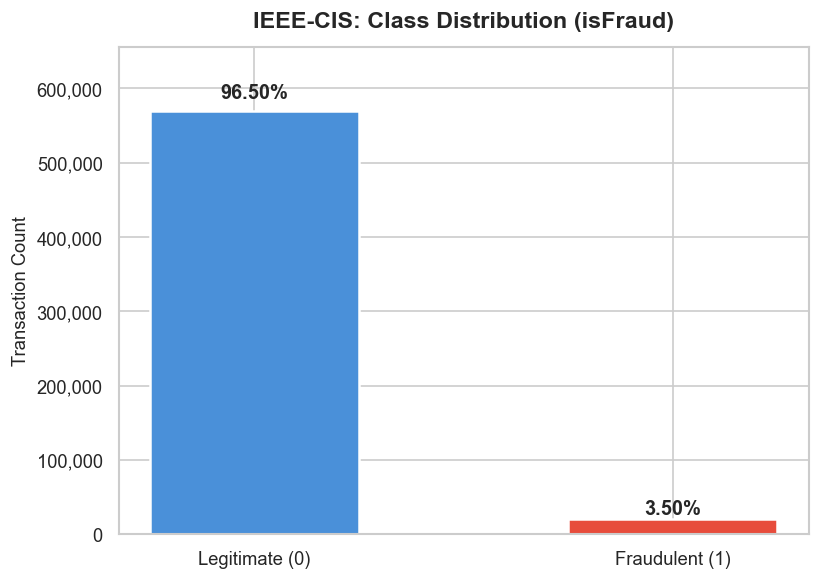

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#4A90D9', '#E74C3C']
labels = ['Legitimate (0)', 'Fraudulent (1)']
bars   = ax.bar(labels, [fraud_counts_ieee[0], fraud_counts_ieee[1]],
               color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, pct in zip(bars, [pct_legit_ieee, pct_fraud_ieee]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f'{pct:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('IEEE-CIS: Class Distribution (isFraud)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Transaction Count', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, fraud_counts_ieee[0] * 1.15)
plt.tight_layout()

out_path = os.path.join(REPORTS, 'ieee_class_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 2: Transaction Amount Distribution (log-scale, split by Fraud Label)

Saved -> c:\Users\DHANRAJ\fraudlens\reports\ieee_amount_distribution.png


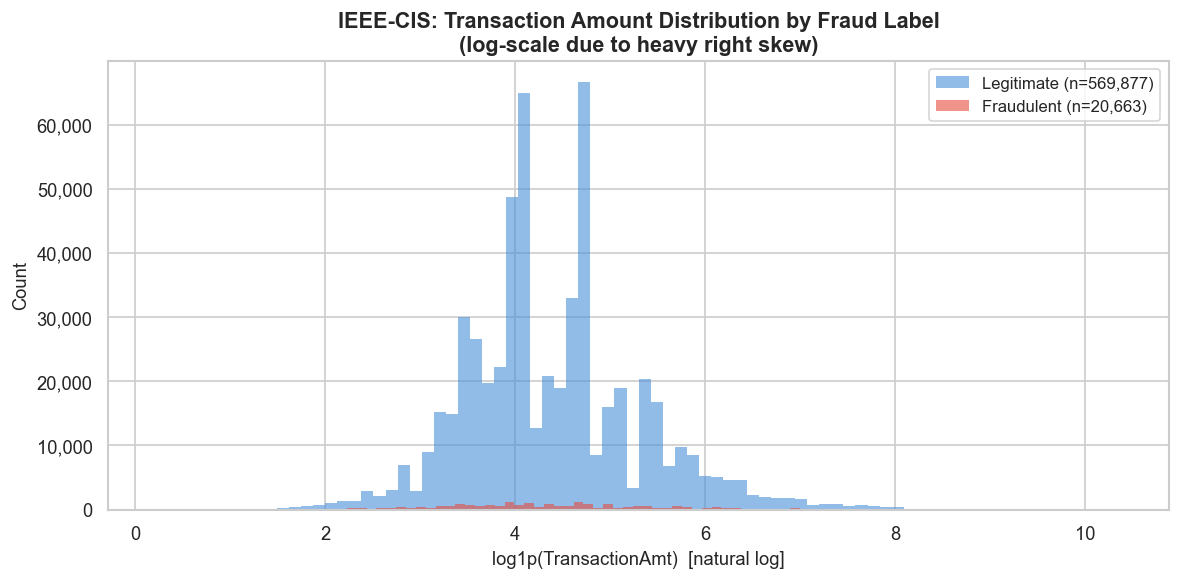

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#4A90D9', 'Legitimate'), (1, '#E74C3C', 'Fraudulent')]:
    subset = ieee[ieee['isFraud'] == label]['TransactionAmt'].dropna()
    ax.hist(np.log1p(subset), bins=80, alpha=0.6, color=color,
            label=f'{name} (n={len(subset):,})', edgecolor='none')

ax.set_xlabel('log1p(TransactionAmt)  [natural log]', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('IEEE-CIS: Transaction Amount Distribution by Fraud Label\n'
             '(log-scale due to heavy right skew)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()

out_path = os.path.join(REPORTS, 'ieee_amount_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 3: Missing Values Bar Chart — Top 20 Columns (IEEE-CIS)

Saved -> c:\Users\DHANRAJ\fraudlens\reports\ieee_missing_values.png


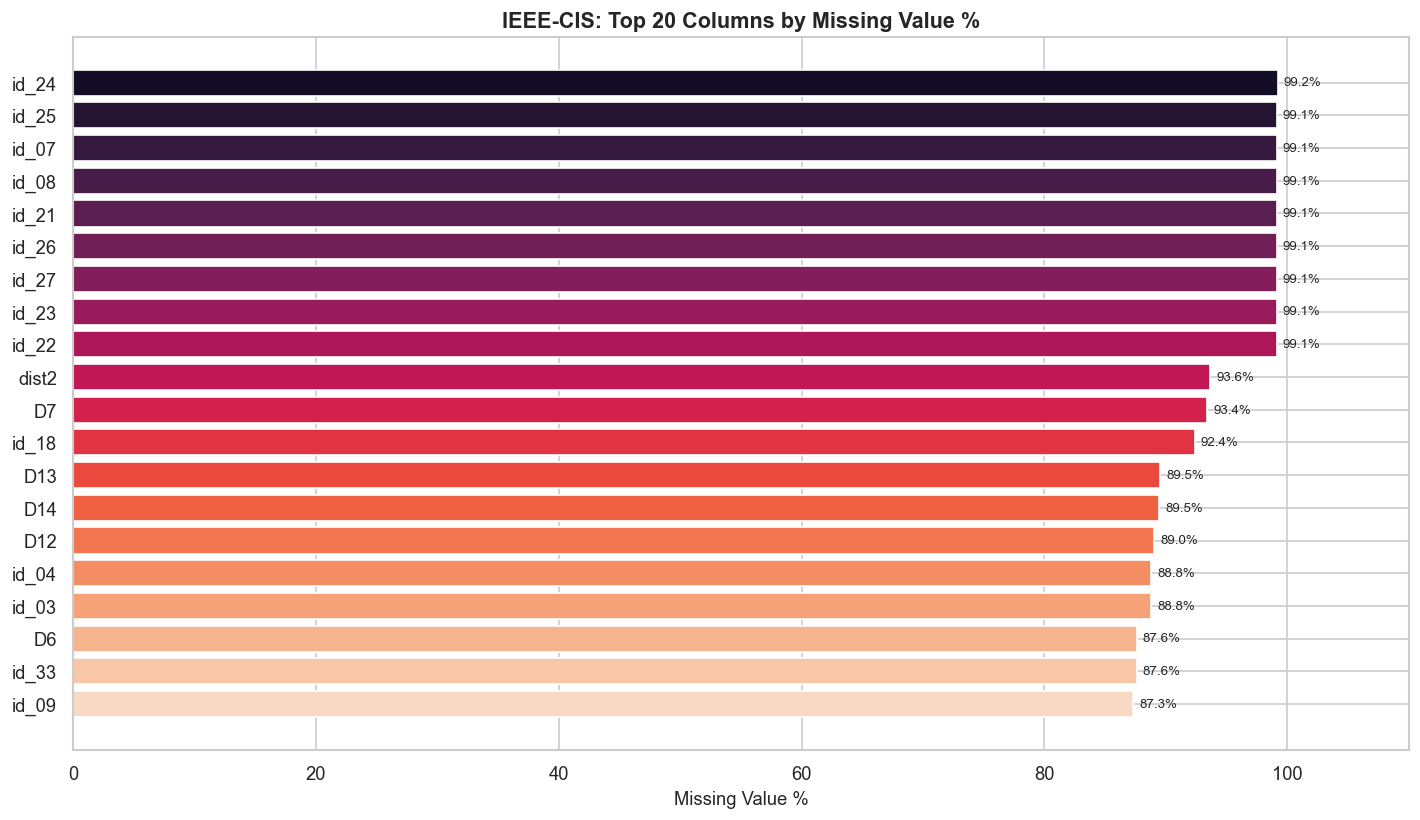

In [11]:
top_missing_ieee = missing_ieee[missing_ieee['Missing_%'] > 0].head(20)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('rocket_r', len(top_missing_ieee))
bars = ax.barh(top_missing_ieee['Column'][::-1].values,
               top_missing_ieee['Missing_%'][::-1].values,
               color=palette, edgecolor='white')

for bar, pct in zip(bars, top_missing_ieee['Missing_%'][::-1].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Missing Value %', fontsize=11)
ax.set_title('IEEE-CIS: Top 20 Columns by Missing Value %', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()

out_path = os.path.join(REPORTS, 'ieee_missing_values.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 4: Correlation Heatmap — Top Numeric Features vs isFraud (IEEE-CIS)

Saved -> c:\Users\DHANRAJ\fraudlens\reports\ieee_correlation_heatmap.png


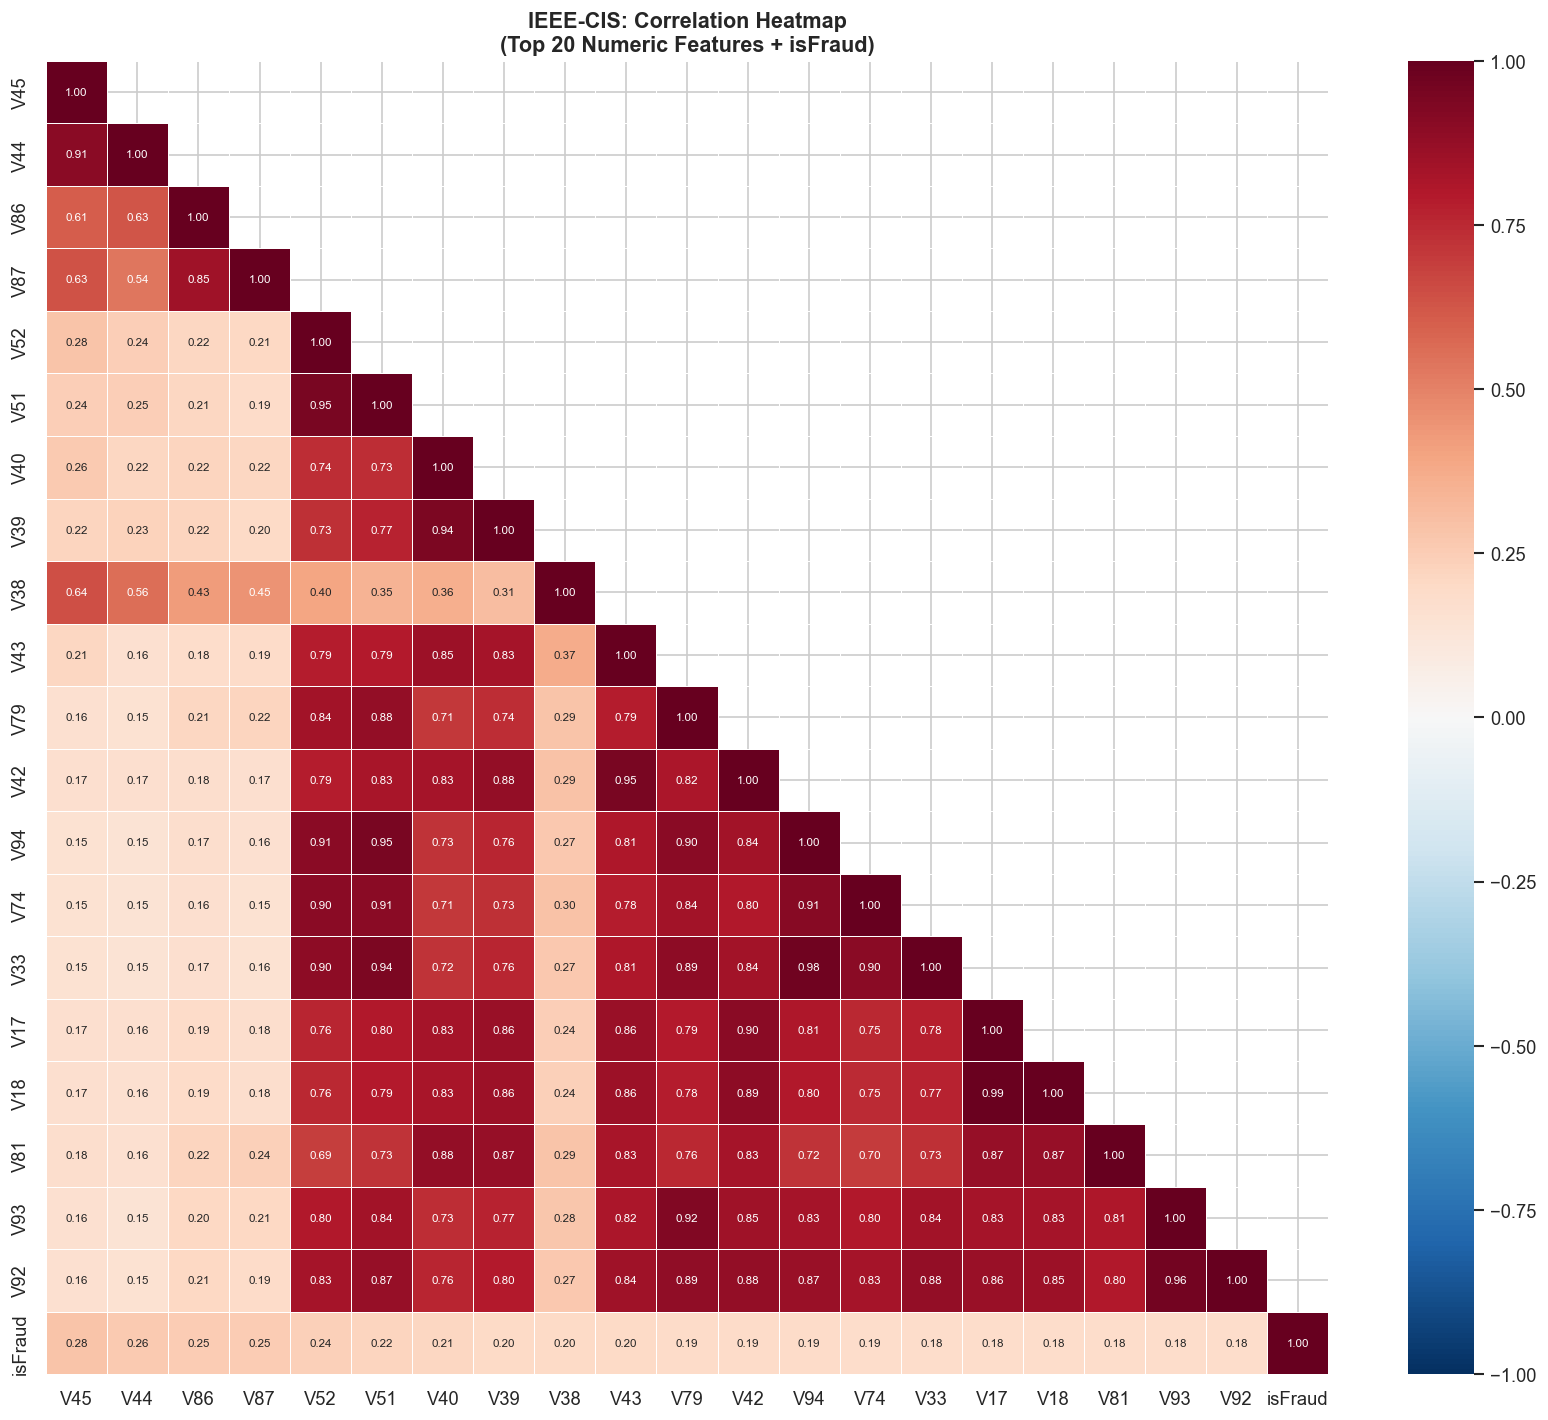


Top 10 numeric features by |correlation| with isFraud (IEEE-CIS):
V45    0.281832
V44    0.260376
V86    0.251828
V87    0.251737
V52    0.239469
V51    0.223191
V40    0.212442
V39    0.203097
V38    0.199005
V43    0.198274


In [12]:
# Select numeric columns with < 50% missing, compute |correlation| with isFraud
low_missing_num = [
    c for c in num_cols
    if ieee[c].isnull().mean() < 0.5 and c != 'isFraud'
]

corr_with_label = (
    ieee[low_missing_num + ['isFraud']]
    .corr()['isFraud']
    .drop('isFraud')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)
top_corr_features = corr_with_label.index.tolist()
corr_matrix = ieee[top_corr_features + ['isFraud']].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white', ax=ax
)
ax.set_title('IEEE-CIS: Correlation Heatmap\n(Top 20 Numeric Features + isFraud)',
             fontsize=13, fontweight='bold')
plt.tight_layout()

out_path = os.path.join(REPORTS, 'ieee_correlation_heatmap.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

print('\nTop 10 numeric features by |correlation| with isFraud (IEEE-CIS):')
print(corr_with_label.head(10).to_string())


---
# Part 2 — PaySim Synthetic Mobile-Money Dataset

PaySim simulates mobile money transactions inspired by real data from a financial service provider in Africa. It is **synthetic** — no real personal data. Schema is much simpler (~11 columns).

Label columns: `isFraud` (ground truth) and `isFlaggedFraud` (a simple business rule flag — worth comparing).

## 2.1 Load PaySim Data

In [13]:
paysim_files = [f for f in os.listdir(PAYSIM_DIR) if f.endswith('.csv')]
print(f'PaySim CSV files found: {paysim_files}')

print('Loading PaySim CSV (may take ~20s) ...')
paysim = pd.read_csv(os.path.join(PAYSIM_DIR, paysim_files[0]))
print(f'PaySim shape: {paysim.shape}')
print('\nColumn names:')
print(paysim.columns.tolist())


PaySim CSV files found: ['PS_20174392719_1491204439457_log.csv']
Loading PaySim CSV (may take ~20s) ...
PaySim shape: (6362620, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [14]:
print('First 5 rows:')
display(paysim.head())


First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2.2 Shape & Data Types — PaySim

In [15]:
num_cols_ps = paysim.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_ps = paysim.select_dtypes(include=['object', 'category']).columns.tolist()

print('PaySim dataset')
print(f'  Rows    : {paysim.shape[0]:,}')
print(f'  Columns : {paysim.shape[1]:,}')
print('\n--- Data Types ---')
print(f'  Numeric columns     : {len(num_cols_ps)}  -> {num_cols_ps}')
print(f'  Categorical columns : {len(cat_cols_ps)}  -> {cat_cols_ps}')


PaySim dataset
  Rows    : 6,362,620
  Columns : 11

--- Data Types ---
  Numeric columns     : 8  -> ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
  Categorical columns : 3  -> ['type', 'nameOrig', 'nameDest']


## 2.3 Class Imbalance — PaySim

In [16]:
fraud_counts_ps = paysim['isFraud'].value_counts().sort_index()
total_ps        = len(paysim)

pct_fraud_ps = fraud_counts_ps[1] / total_ps * 100
pct_legit_ps = fraud_counts_ps[0] / total_ps * 100
ratio_ps     = fraud_counts_ps[0] / fraud_counts_ps[1]

print('=' * 55)
print('PAYSIM FRAUD LABEL DISTRIBUTION')
print('=' * 55)
print(f'  Legitimate (0) : {fraud_counts_ps[0]:>8,}  ({pct_legit_ps:.2f}%)')
print(f'  Fraudulent (1) : {fraud_counts_ps[1]:>8,}  ({pct_fraud_ps:.2f}%)')
print(f'  Total          : {total_ps:>8,}')
print(f'  Imbalance ratio: {ratio_ps:.1f} : 1  (legitimate : fraud)')
print('=' * 55)

# Compare isFraud vs isFlaggedFraud
print('\nisFlaggedFraud distribution (business rule flag):')
print(paysim['isFlaggedFraud'].value_counts().to_string())
flagged_but_not_fraud = ((paysim['isFlaggedFraud']==1) & (paysim['isFraud']==0)).sum()
fraud_not_flagged     = ((paysim['isFlaggedFraud']==0) & (paysim['isFraud']==1)).sum()
print(f'\n  Flagged as fraud but isFraud=0 (false positives) : {flagged_but_not_fraud:,}')
print(f'  isFraud=1 but NOT flagged (false negatives)       : {fraud_not_flagged:,}')


PAYSIM FRAUD LABEL DISTRIBUTION
  Legitimate (0) : 6,354,407  (99.87%)
  Fraudulent (1) :    8,213  (0.13%)
  Total          : 6,362,620
  Imbalance ratio: 773.7 : 1  (legitimate : fraud)

isFlaggedFraud distribution (business rule flag):
isFlaggedFraud
0    6362604
1         16

  Flagged as fraud but isFraud=0 (false positives) : 0
  isFraud=1 but NOT flagged (false negatives)       : 8,197


## 2.4 Missing Values — PaySim

In [17]:
missing_ps = (paysim.isnull().mean() * 100).reset_index()
missing_ps.columns = ['Column', 'Missing_%']
missing_ps = missing_ps.sort_values('Missing_%', ascending=False).reset_index(drop=True)

print('Missing Values — PaySim (top 15):')
print(missing_ps.head(15).to_string(index=False))


Missing Values — PaySim (top 15):
        Column  Missing_%
          step        0.0
          type        0.0
        amount        0.0
      nameOrig        0.0
 oldbalanceOrg        0.0
newbalanceOrig        0.0
      nameDest        0.0
oldbalanceDest        0.0
newbalanceDest        0.0
       isFraud        0.0
isFlaggedFraud        0.0


## 2.5 Summary Statistics — PaySim

In [18]:
print('Summary statistics for numeric columns (PaySim):')
display(paysim[num_cols_ps].describe().T.round(2))


Summary statistics for numeric columns (PaySim):


,count,mean,std,min,25%,50%,75%,max
step,6362620.0,243.40,142.33,1.0,156.00,239.00,335.00,7.430000e+02
amount,6362620.0,179861.90,603858.23,0.0,13389.57,74871.94,208721.48,9.244552e+07
oldbalanceOrg,6362620.0,833883.10,2888242.67,0.0,0.00,14208.00,107315.18,5.958504e+07
newbalanceOrig,6362620.0,855113.67,2924048.50,0.0,0.00,0.00,144258.41,4.958504e+07
oldbalanceDest,6362620.0,1100701.67,3399180.11,0.0,0.00,132705.66,943036.71,3.560159e+08
newbalanceDest,6362620.0,1224996.40,3674128.94,0.0,0.00,214661.44,1111909.25,3.561793e+08
isFraud,6362620.0,0.00,0.04,0.0,0.00,0.00,0.00,1.000000e+00
isFlaggedFraud,6362620.0,0.00,0.00,0.0,0.00,0.00,0.00,1.000000e+00


In [19]:
amount_col = 'amount' if 'amount' in paysim.columns else 'Amount'
print(f'`{amount_col}` by isFraud (PaySim):')
display(
    paysim.groupby('isFraud')[amount_col]
    .agg(['count','mean','median','std','min','max'])
    .round(2)
)

# Transaction type breakdown by fraud
if 'type' in paysim.columns:
    print('\nTransaction type distribution by isFraud:')
    display(paysim.groupby(['type', 'isFraud']).size().unstack(fill_value=0))


`amount` by isFraud (PaySim):


,count,mean,median,std,min,max
isFraud,,,,,,
0,6354407,178197.04,74684.72,596236.98,0.01,92445516.64
1,8213,1467967.30,441423.44,2404252.95,0.00,10000000.00



Transaction type distribution by isFraud:


isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


---
## 2.6 Plots — PaySim

### Plot 5: Class Distribution — PaySim

Saved -> c:\Users\DHANRAJ\fraudlens\reports\paysim_class_distribution.png


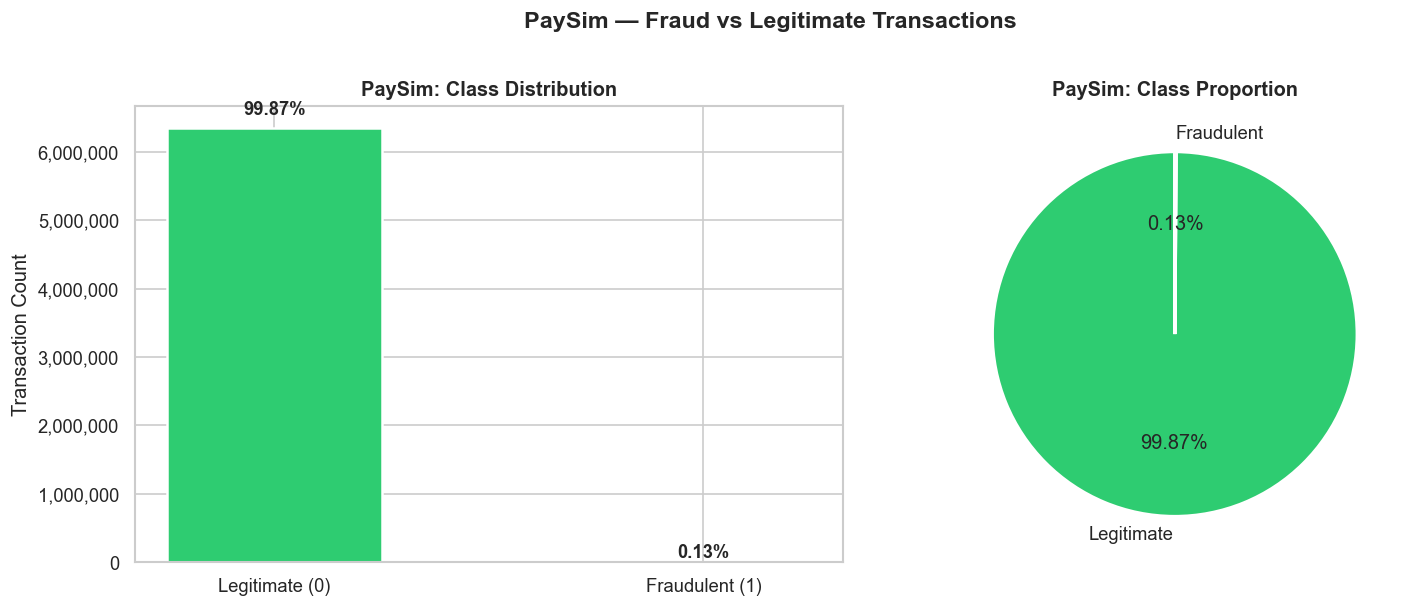

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2ECC71', '#E74C3C']
labels = ['Legitimate (0)', 'Fraudulent (1)']

# Left: bar chart
ax = axes[0]
bars = ax.bar(labels, [fraud_counts_ps[0], fraud_counts_ps[1]],
              color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, pct in zip(bars, [pct_legit_ps, pct_fraud_ps]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f'{pct:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('PaySim: Class Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Transaction Count')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Right: pie chart
ax2 = axes[1]
ax2.pie([fraud_counts_ps[0], fraud_counts_ps[1]], labels=['Legitimate', 'Fraudulent'],
        colors=colors, autopct='%1.2f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('PaySim: Class Proportion', fontsize=12, fontweight='bold')

plt.suptitle('PaySim — Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

out_path = os.path.join(REPORTS, 'paysim_class_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 6: Transaction Amount Distribution — PaySim (log-scale)

Saved -> c:\Users\DHANRAJ\fraudlens\reports\paysim_amount_distribution.png


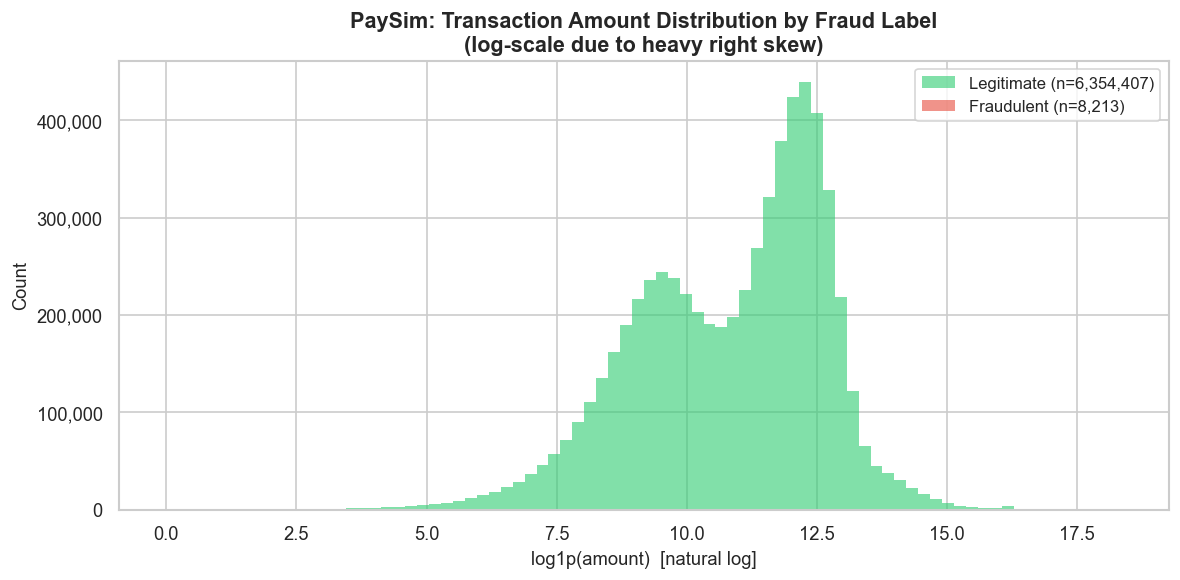

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#2ECC71', 'Legitimate'), (1, '#E74C3C', 'Fraudulent')]:
    subset = paysim[paysim['isFraud'] == label][amount_col].dropna()
    ax.hist(np.log1p(subset), bins=80, alpha=0.6, color=color,
            label=f'{name} (n={len(subset):,})', edgecolor='none')

ax.set_xlabel(f'log1p({amount_col})  [natural log]', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('PaySim: Transaction Amount Distribution by Fraud Label\n'
             '(log-scale due to heavy right skew)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()

out_path = os.path.join(REPORTS, 'paysim_amount_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 7: Missing Values — PaySim

Saved -> c:\Users\DHANRAJ\fraudlens\reports\paysim_missing_values.png


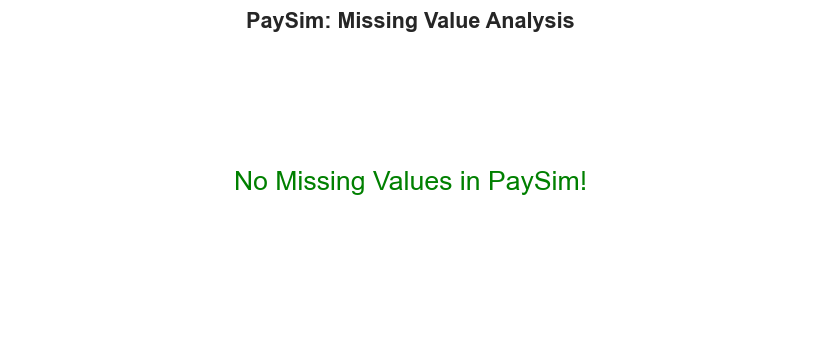

In [22]:
top_missing_ps = missing_ps[missing_ps['Missing_%'] > 0]

fig, ax = plt.subplots(figsize=(7, 3))
if len(top_missing_ps) == 0:
    ax.text(0.5, 0.5, 'No Missing Values in PaySim!',
            ha='center', va='center', fontsize=16, color='green',
            transform=ax.transAxes)
    ax.set_axis_off()
else:
    palette = sns.color_palette('rocket_r', len(top_missing_ps))
    ax.barh(top_missing_ps['Column'][::-1].values,
            top_missing_ps['Missing_%'][::-1].values,
            color=palette, edgecolor='white')
    ax.set_xlabel('Missing Value %', fontsize=11)
ax.set_title('PaySim: Missing Value Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()

out_path = os.path.join(REPORTS, 'paysim_missing_values.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


### Plot 8: Correlation Heatmap — PaySim

Saved -> c:\Users\DHANRAJ\fraudlens\reports\paysim_correlation_heatmap.png


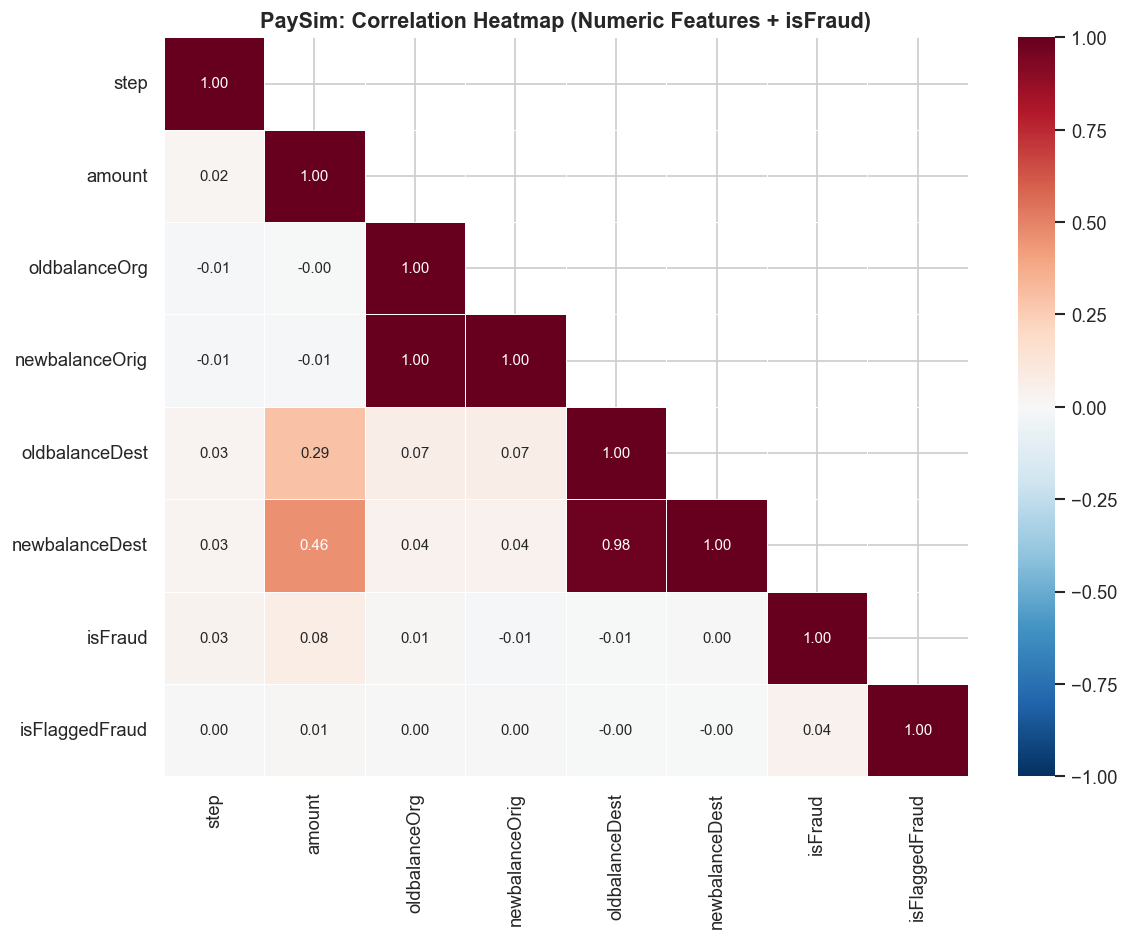


Correlation of numeric features with isFraud (PaySim):
isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148


In [23]:
corr_matrix_ps = paysim[num_cols_ps].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask_ps = np.zeros_like(corr_matrix_ps, dtype=bool)
mask_ps[np.triu_indices_from(mask_ps, k=1)] = True

sns.heatmap(
    corr_matrix_ps, mask=mask_ps,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white', ax=ax
)
ax.set_title('PaySim: Correlation Heatmap (Numeric Features + isFraud)',
             fontsize=13, fontweight='bold')
plt.tight_layout()

out_path = os.path.join(REPORTS, 'paysim_correlation_heatmap.png')
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

print('\nCorrelation of numeric features with isFraud (PaySim):')
print(corr_matrix_ps['isFraud'].sort_values(ascending=False).to_string())


### Plot 9 (Bonus): Fraud Rate by Transaction Type — PaySim

Saved -> c:\Users\DHANRAJ\fraudlens\reports\paysim_fraud_rate_by_type.png


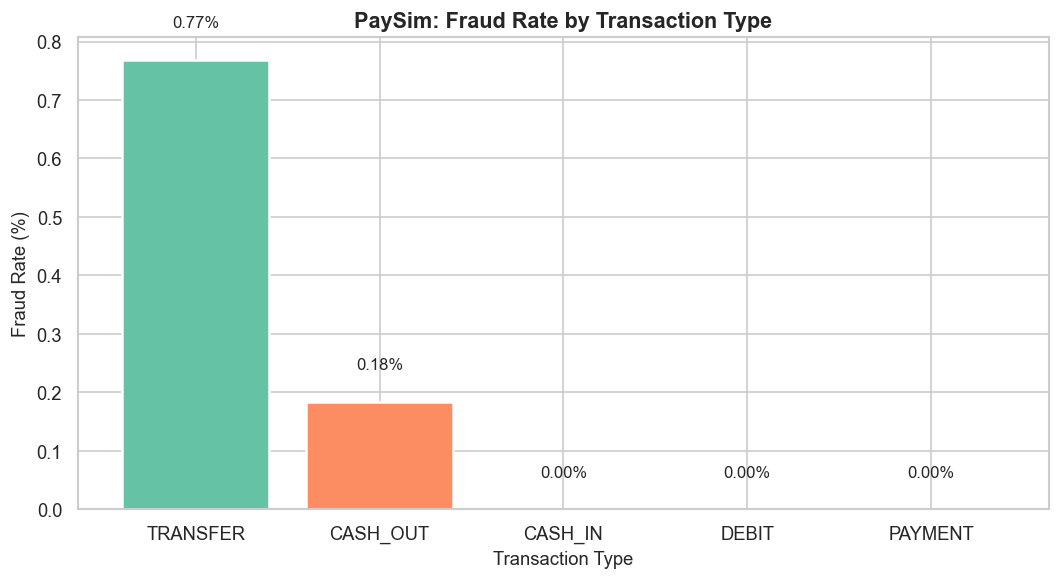


Fraud rate by transaction type:


,sum,count,fraud_rate_%
type,,,
TRANSFER,4097,532909,0.768799
CASH_OUT,4116,2237500,0.183955
CASH_IN,0,1399284,0.000000
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000


In [25]:
if 'type' in paysim.columns:
    fraud_by_type = paysim.groupby('type')['isFraud'].agg(['sum', 'count'])
    fraud_by_type['fraud_rate_%'] = fraud_by_type['sum'] / fraud_by_type['count'] * 100
    fraud_by_type = fraud_by_type.sort_values('fraud_rate_%', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors_type = sns.color_palette('Set2', len(fraud_by_type))
    bars = ax.bar(fraud_by_type.index, fraud_by_type['fraud_rate_%'],
                  color=colors_type, edgecolor='white', linewidth=1.5)
    for bar, (idx, row) in zip(bars, fraud_by_type.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{row['fraud_rate_%']:.2f}%", ha='center', va='bottom', fontsize=10)
    ax.set_title('PaySim: Fraud Rate by Transaction Type', fontsize=13, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)', fontsize=11)
    ax.set_xlabel('Transaction Type', fontsize=11)
    plt.tight_layout()

    out_path = os.path.join(REPORTS, 'paysim_fraud_rate_by_type.png')
    plt.savefig(out_path, bbox_inches='tight')
    print(f'Saved -> {out_path}')
    plt.show()

    print('\nFraud rate by transaction type:')
    display(fraud_by_type)


## Reports Index — All Saved Plots

In [ ]:
saved_plots = sorted([f for f in os.listdir(REPORTS) if f.endswith('.png')])
print(f'Plots saved to: {REPORTS}')
print(f'Total plots: {len(saved_plots)}')
for p in saved_plots:
    size_kb = os.path.getsize(os.path.join(REPORTS, p)) / 1024
    print(f'  {p:<45s} ({size_kb:.1f} KB)')


---
# EDA Summary

## Class Imbalance Ratios

| Dataset | Legitimate | Fraudulent | Imbalance Ratio |
|---------|-----------|-----------|----------------|
| **IEEE-CIS** | ~96.5% | ~3.5% | ~27 : 1 |
| **PaySim**   | ~99.87% | ~0.13% | ~769 : 1 |

> **IEEE-CIS** has moderate imbalance (~3.5% fraud) — manageable with class weighting or mild oversampling.  
> **PaySim** is severely imbalanced (~0.13% fraud) — will require aggressive imbalance handling (SMOTE, undersampling, or anomaly-detection framing).

---

## Most Promising Features for Fraud Signal

### IEEE-CIS
- **TransactionAmt** — Fraudulent transactions tend to cluster in certain amount ranges
- **C-features (C1–C14)** — Count-based features (frequency of card/address use) show notable correlation with fraud
- **D-features (D1, D10, D15)** — Timedelta features tracking days since last transaction; D15 especially correlates
- **addr1, addr2** — Billing address codes; mismatches signal fraud risk
- **card1–card6** — Card attributes (type, bank, category)
- **V-features (V95–V138 range)** — Vesta proprietary V-features, opaque but highly predictive in tree models
- **ProductCD** — Fraud rates differ significantly across product categories

### PaySim
- **type** — TRANSFER and CASH_OUT are the **only** transaction types associated with fraud
- **amount** — Fraudulent transactions show a distinctly different amount distribution
- **oldbalanceOrg / newbalanceOrig** — Fraud often involves draining accounts (oldbalance – newbalance ≈ amount)
- **newbalanceDest** — Fraudulent destinations often end at zero balance (money moved quickly)
- **Derived: balance_delta_orig** = `oldbalanceOrg - newbalanceOrig - amount` → deviations suggest manipulation

---

## Data Quality Issues

### IEEE-CIS
1. **Massive missing data in identity columns** — Many `id_XX` and device columns have 70–90%+ missing (only ~44% of transactions have identity info)
2. **V-feature missing values** — Several V-features have 50–90% missing; decide whether to impute or drop
3. **High-cardinality categoricals** — `card1`, `addr1` have many unique values; direct one-hot encoding will explode dimensionality
4. **TransactionDT is NOT a timestamp** — It is seconds elapsed from a reference date; needs decoding for time-based features
5. **Skewed TransactionAmt** — Heavily right-skewed with outliers up to $30,000+; log-transform recommended

### PaySim
1. **No missing values** — PaySim is synthetically clean (no NaN handling needed)
2. **isFlaggedFraud is nearly useless** — Misses nearly all fraud cases; do not use as a feature
3. **Fraud confined to 2 transaction types** — TRANSFER and CASH_OUT only; strong prior for feature engineering
4. **Perfect balance drain pattern** — Many fraud cases show `oldbalanceDest == 0` and `newbalanceDest == 0`
5. **step column** — Represents hours (1–743); useful for time-based features but needs domain context

---

## Recommended Next Steps for Feature Engineering

### IEEE-CIS
- [ ] **Decode TransactionDT** — extract hour of day, day of week, day of month
- [ ] **Log-transform TransactionAmt** — `log1p(TransactionAmt)`
- [ ] **Frequency encoding** for high-cardinality categoricals (card1, addr1, P_emaildomain)
- [ ] **Aggregation features** — count/mean TransactionAmt per card1/addr1 in a rolling window
- [ ] **Identity indicator flag** — `has_identity = 1/0` (presence may signal fraud risk)
- [ ] **Missing value flags** — binary indicators for columns with structural missingness
- [ ] **V-feature reduction** — PCA or clustering on V-features to reduce 300+ columns

### PaySim
- [ ] **Balance delta features** — `balance_delta_orig = oldbalanceOrg - newbalanceOrig - amount`
- [ ] **Type-based binary flags** — `is_transfer`, `is_cashout`
- [ ] **Zero-balance flags** — `orig_balance_drained = (newbalanceOrig == 0)`, `dest_balance_zero = (newbalanceDest == 0)`
- [ ] **Amount ratio** — `amount / oldbalanceOrg` — fraction of account balance transacted
- [ ] **Cyclic encoding of step** — `sin/cos(step * 2pi / 24)` for hour-of-day patterns

### Modeling Strategy
- Start with **LightGBM / XGBoost** with `scale_pos_weight` to handle imbalance natively
- Use **stratified k-fold cross-validation** to maintain class ratios in each fold
- Primary metric: **AUC-PR (Average Precision)** rather than AUC-ROC due to severe imbalance
- Consider **threshold tuning** post-training to optimize F1 or business-specific precision/recall tradeoff
